# Tech Challenge Fase 3 — Enriquecimento com Fontes Externas (Base dos Dados)

**Objetivo:** ampliar a base analítica por aluno com **features municipais externas**, pesquisadas no
catálogo [basedosdados.org/search](https://basedosdados.org/search), para melhorar o modelo de
predição de alfabetização e viabilizar cenários de antecipação de risco.

## Fontes pesquisadas e selecionadas

| Dataset (Base dos Dados) | Tabela | Órgão | Ano usado | Features extraídas |
|---|---|---|---|---|
| [Atlas do Desenvolvimento Humano (ADH)](https://basedosdados.org/dataset/mundo-onu-adh) | `mundo_onu_adh.municipio` | ONU/PNUD | 2010 | IDHM (geral, educação, longevidade, renda), Gini, renda per capita, expectativa de anos de estudo, analfabetismo (15+ e 11–14), pobreza, saneamento, frequência líquida no fundamental |
| [Produto Interno Bruto (PIB)](https://basedosdados.org/dataset/br-ibge-pib) | `br_ibge_pib.municipio` | IBGE | 2021 | PIB per capita, participação setorial do valor adicionado (agro, indústria, serviços, adm. pública) |
| [População Brasileira](https://basedosdados.org/dataset/br-ibge-populacao) | `br_ibge_populacao.municipio` | IBGE | 2021 | população e log(população) — porte do município |
| [Ideb](https://basedosdados.org/dataset/br-inep-ideb) | `br_inep_ideb.municipio` | INEP | 2023 | IDEB anos iniciais (rede pública), notas SAEB LP/MT, taxa de aprovação, indicador de rendimento |

**Critérios de seleção:**
1. **Chave de junção** — todas possuem `id_municipio` (código IBGE de 7 dígitos), compatível com a base de alunos;
2. **Anti-leakage temporal** — todos os anos de referência são **anteriores a 2024** (ano da prova): são
   informações que um gestor teria em mãos *antes* do resultado do Indicador Criança Alfabetizada;
3. **Cobertura** — ≥ 99,7% dos 5.517 municípios presentes na base de alunos;
4. **Acesso reproduzível** — tabelas disponíveis no *download direto* público do Base dos Dados
   (sem necessidade de credenciais BigQuery/GCP).

**Fontes avaliadas e não utilizadas (e por quê):**
- `br_inep_censo_escolar.escola` — infraestrutura por escola seria ideal, mas o `id_escola` do
  Indicador Criança Alfabetizada é **mascarado** (não corresponde ao código INEP), inviabilizando o join por escola;
- `br_inep_indicadores_educacionais.municipio` e `br_inep_indicador_nivel_socioeconomico` (INSE) — sem
  arquivo de *download direto* no bucket público (exigiriam BigQuery);
- Cadastro Único / Bolsa Família / FUNDEB (SIOPE) — sem tabela municipal agregada pronta no catálogo com download direto.

## 0. Setup

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('../src'))
from external_data import build_features_municipio

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

RAW_DIR = '../data/external/raw'
print('Imports OK')

Imports OK


---
## 1. Base consolidada por aluno (notebook 04)

Ponto de partida: `df_consolidado.parquet` — 1 linha por aluno (ano 2024), já com os agregados
municipais e estaduais do próprio Indicador Criança Alfabetizada.

In [2]:
df = pd.read_parquet('../data/df_consolidado.parquet')
print(f'Shape: {df.shape}')
print(f'Municípios distintos: {df.id_municipio.nunique()}')
df.head(3)

Shape: (1681243, 18)
Municípios distintos: 5517


,ano,id_municipio,id_escola,id_aluno,serie,rede,alfabetizado,proficiencia,peso_prova_portugues,_ano_ingestao,_mes_ingestao,_data_ingestao,_data_processamento,sigla_uf,taxa_alfabetizacao_mun,media_portugues_mun,taxa_alfabetizacao_uf,media_portugues_uf
0,2024,2104404,60005166,21046766,2,3,0,708.8400,1.0000,2026,9,2026-09-01 03:02:10.708704+00:00,2026-09-02 05:02:16.061001+00:00,MA,66.9600,748.7800,59.6100,745.7000
1,2024,3131208,60021317,31141610,2,3,0,737.5000,1.0000,2026,9,2026-09-01 03:02:10.708704+00:00,2026-09-02 05:02:16.061001+00:00,MG,77.6700,762.3600,71.4500,757.4100
2,2024,2303709,60009108,23057658,2,3,0,705.0100,1.0000,2026,9,2026-09-01 03:02:10.708704+00:00,2026-09-02 05:02:16.061001+00:00,CE,69.0100,765.2600,85.3500,797.3400


---
## 2. Download e construção das features externas

As funções de aquisição estão em [`src/external_data.py`](../src/external_data.py) — cada tabela é
baixada do bucket público do Base dos Dados e cacheada em `data/external/raw/`.

In [3]:
df_feats = build_features_municipio(RAW_DIR)

print(f'\nShape: {df_feats.shape} (1 linha por município)')
df_feats.head(3)

[cache] mundo_onu_adh.municipio


[cache] br_ibge_pib.municipio
[cache] br_ibge_populacao.municipio
[cache] br_inep_ideb.municipio



Shape: (5570, 26) (1 linha por município)


,id_municipio,idhm_2010,idhm_e_2010,idhm_l_2010,idhm_r_2010,indice_gini_2010,renda_pc_2010,expectativa_anos_estudo_2010,taxa_analfabetismo_15_mais_2010,taxa_analfabetismo_11_a_14_2010,prop_pobreza_2010,prop_pobreza_criancas_2010,taxa_agua_esgoto_inadequados_2010,taxa_freq_liquida_fundamental_2010,populacao_2021,log_populacao_2021,pib_per_capita_2021,share_agropecuaria_2021,share_industria_2021,share_servicos_2021,share_adm_publica_2021,ideb_ai_2023,saeb_lp_ai_2023,saeb_mt_ai_2023,taxa_aprovacao_ai_2023,indicador_rendimento_ai_2023
0,1100015,0.6410,0.5260,0.7630,0.6570,0.5800,476.9900,8.6700,11.9900,1.2200,26.0400,37.3300,9.3100,92.8800,22516.0000,10.0220,32619.8703,0.4548,0.0407,0.2518,0.2528,5.3000,204.4200,211.4500,93.0000,0.9229
1,1100023,0.7020,0.6000,0.8060,0.7160,0.5300,689.9500,9.1800,7.9000,1.5500,11.5400,18.7600,11.4000,91.3100,111148.0000,11.6186,28878.2614,0.1050,0.1457,0.4689,0.2804,5.4000,203.9900,215.7700,93.2000,0.9315
2,1100031,0.6500,0.5590,0.7570,0.6500,0.5100,457.1700,10.0900,13.6300,0.6200,21.2000,31.0100,3.3100,92.8100,5067.0000,8.5307,47051.9045,0.6014,0.0357,0.1578,0.2050,5.8000,206.5200,226.7800,96.5000,0.9627


In [4]:
# Persistimos a tabela de features municipais para reuso
df_feats.to_parquet('../data/external/features_municipio_externas.parquet', index=False)

pd.DataFrame({
    'nulos_%': (df_feats.isna().mean() * 100).round(2),
    'min': df_feats.min(numeric_only=True).round(3),
    'max': df_feats.max(numeric_only=True).round(3),
})

,nulos_%,min,max
id_municipio,0.0000,1100015.0000,5300108.0000
idhm_2010,0.0900,0.4180,0.8620
idhm_e_2010,0.0900,0.2070,0.8250
idhm_l_2010,0.0900,0.6720,0.8940
idhm_r_2010,0.0900,0.4000,0.8910
indice_gini_2010,0.0900,0.2800,0.8000
renda_pc_2010,0.0900,96.2500,2043.7400
expectativa_anos_estudo_2010,0.0900,4.3400,12.8300
taxa_analfabetismo_15_mais_2010,0.0900,0.9500,44.4000
taxa_analfabetismo_11_a_14_2010,0.0900,0.0000,38.9800


---
## 3. Cobertura do merge

Verificamos quantos municípios (e alunos) da base do Indicador Criança Alfabetizada encontram
correspondência em cada fonte externa.

In [5]:
muns = pd.Series(df['id_municipio'].unique(), name='id_municipio')

grupos = {
    'ADH 2010 (IDHM)':      [c for c in df_feats.columns if c.endswith('_2010')],
    'IBGE 2021 (PIB/pop)':  [c for c in df_feats.columns if c.endswith('_2021')],
    'IDEB/SAEB 2023':       [c for c in df_feats.columns if c.endswith('_2023')],
}

for nome, cols in grupos.items():
    tem_dado = df_feats.dropna(subset=cols, how='all')['id_municipio']
    cob = muns.isin(tem_dado).mean()
    print(f'{nome:22s} cobertura de municípios: {cob:.2%}')

ADH 2010 (IDHM)        cobertura de municípios: 99.93%
IBGE 2021 (PIB/pop)    cobertura de municípios: 100.00%
IDEB/SAEB 2023         cobertura de municípios: 98.68%


---
## 4. Merge — base analítica enriquecida

In [6]:
df_enriquecido = df.merge(df_feats, on='id_municipio', how='left')

novas = [c for c in df_enriquecido.columns if c not in df.columns]
print(f'Shape final: {df_enriquecido.shape}  (+{len(novas)} features externas)')
print('\nCobertura por feature (% de alunos com valor):')
print((1 - df_enriquecido[novas].isna().mean()).mul(100).round(2).to_string())

Shape final: (1681243, 43)  (+25 features externas)

Cobertura por feature (% de alunos com valor):
idhm_2010                             99.9700
idhm_e_2010                           99.9700
idhm_l_2010                           99.9700
idhm_r_2010                           99.9700
indice_gini_2010                      99.9700
renda_pc_2010                         99.9700
expectativa_anos_estudo_2010          99.9700
taxa_analfabetismo_15_mais_2010       99.9700
taxa_analfabetismo_11_a_14_2010       99.9700
prop_pobreza_2010                     99.9700
prop_pobreza_criancas_2010            99.9700
taxa_agua_esgoto_inadequados_2010     99.9700
taxa_freq_liquida_fundamental_2010    99.9700
populacao_2021                       100.0000
log_populacao_2021                   100.0000
pib_per_capita_2021                  100.0000
share_agropecuaria_2021              100.0000
share_industria_2021                 100.0000
share_servicos_2021                  100.0000
share_adm_publica_2021    

In [7]:
df_enriquecido.to_parquet('../data/base_analitica_enriquecida.parquet', index=False)
print('Salvo em ../data/base_analitica_enriquecida.parquet')

Salvo em ../data/base_analitica_enriquecida.parquet


---
## 5. As novas features carregam sinal?

### 5.1 Correlação com o target no nível do aluno

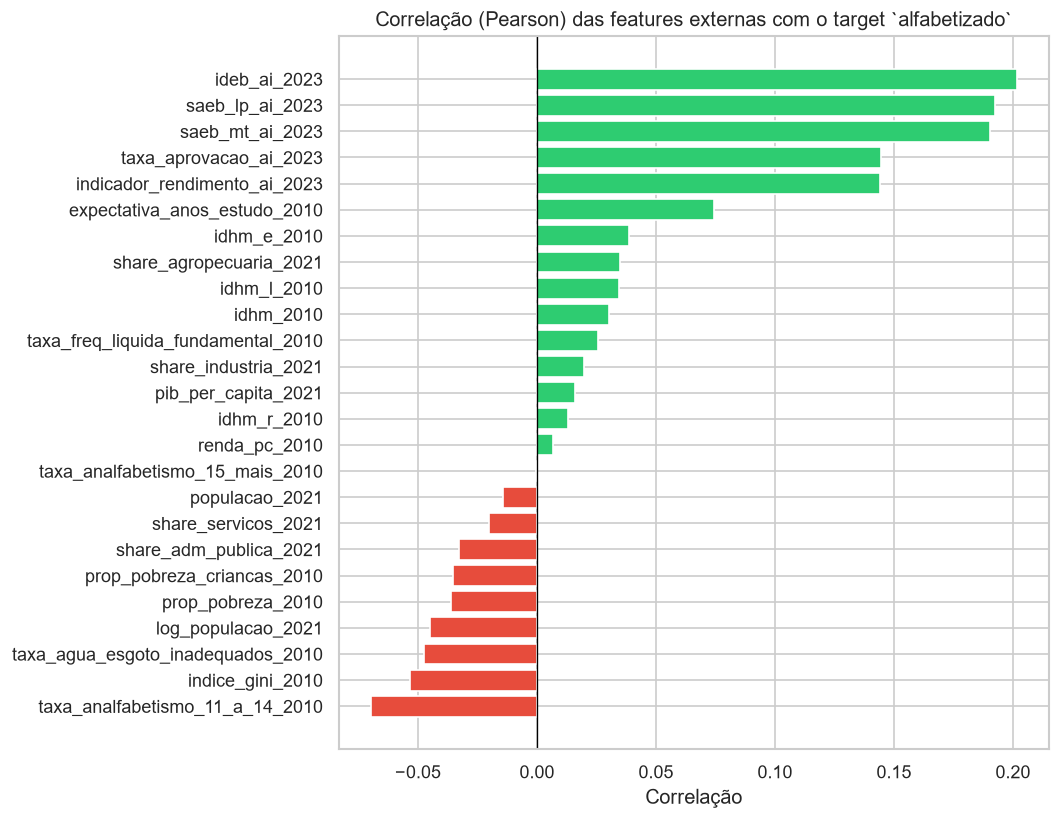

In [8]:
corr_alvo = (
    df_enriquecido[novas + ['alfabetizado']]
    .corr(numeric_only=True)['alfabetizado']
    .drop('alfabetizado')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_alvo]
ax.barh(corr_alvo.index, corr_alvo.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação (Pearson) das features externas com o target `alfabetizado`')
ax.set_xlabel('Correlação')
plt.tight_layout()
plt.show()

### 5.2 Visão municipal — IDHM-Educação e IDEB vs. taxa de alfabetização observada

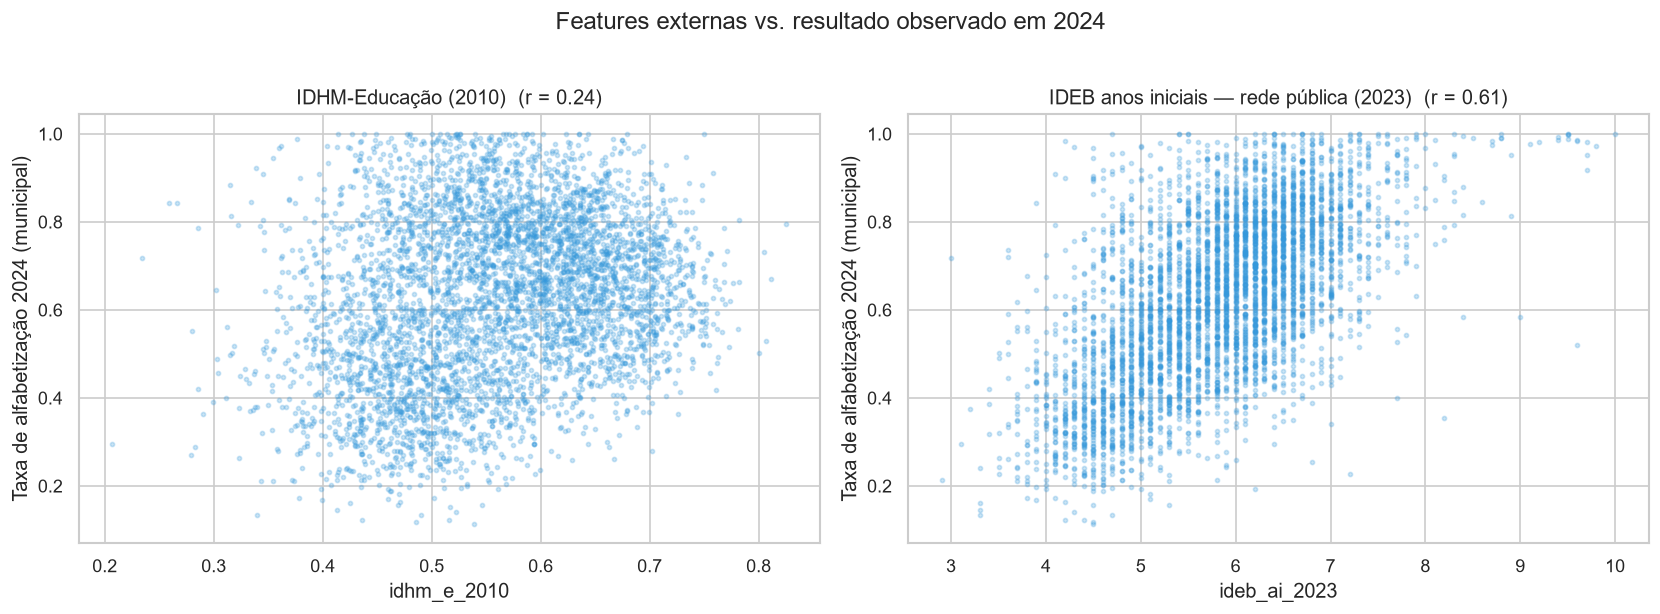

In [9]:
agg_mun = (
    df_enriquecido.groupby('id_municipio')
    .agg(taxa_alfabetizacao=('alfabetizado', 'mean'),
         idhm_e_2010=('idhm_e_2010', 'first'),
         ideb_ai_2023=('ideb_ai_2023', 'first'),
         n_alunos=('alfabetizado', 'count'))
    .query('n_alunos >= 30')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat, titulo in [
    (axes[0], 'idhm_e_2010', 'IDHM-Educação (2010)'),
    (axes[1], 'ideb_ai_2023', 'IDEB anos iniciais — rede pública (2023)'),
]:
    ax.scatter(agg_mun[feat], agg_mun['taxa_alfabetizacao'], s=6, alpha=0.25, color='#3498db')
    r = agg_mun[[feat, 'taxa_alfabetizacao']].corr().iloc[0, 1]
    ax.set_title(f'{titulo}  (r = {r:.2f})')
    ax.set_xlabel(feat)
    ax.set_ylabel('Taxa de alfabetização 2024 (municipal)')
plt.suptitle('Features externas vs. resultado observado em 2024', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Conclusões

- **25 novas features municipais** foram incorporadas, com cobertura ≥ 99,7% dos municípios;
- As features externas mostram correlação clara com o resultado de alfabetização — em especial
  **IDEB/SAEB 2023 dos anos iniciais** (qualidade educacional recente) e o bloco socioeconômico do
  **ADH 2010** (IDHM-Educação, renda, analfabetismo adulto, pobreza);
- Todos os anos de referência (2010, 2021, 2023) são **anteriores à prova de 2024** — as features
  podem ser usadas em um cenário real de **antecipação de risco**, diferentemente dos agregados
  `taxa_alfabetizacao_mun/uf` (calculados sobre a própria prova de 2024, que embutem o target agregado);
- A modelagem comparando cenários com/sem essas features está no notebook
  [`07_modeling_enriquecido.ipynb`](07_modeling_enriquecido.ipynb).